In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import random
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Traffic.csv')
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 non-null   int64 
 7   Total              2976 non-null   int64 
 8   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(3)
memory usage: 209.4+ KB


In [5]:
df = df.dropna()

In [6]:
del df['Time']

In [7]:
df['Day of the week'].value_counts()

Thursday     480
Wednesday    480
Tuesday      480
Friday       384
Monday       384
Saturday     384
Sunday       384
Name: Day of the week, dtype: int64

In [8]:
df['Traffic Situation'].value_counts()

normal    1669
heavy      682
high       321
low        304
Name: Traffic Situation, dtype: int64

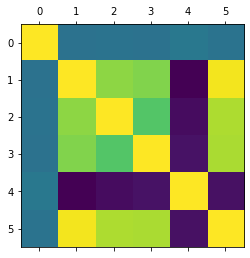

In [9]:
import matplotlib.pyplot as plt

plt.matshow(df.corr())
plt.show()

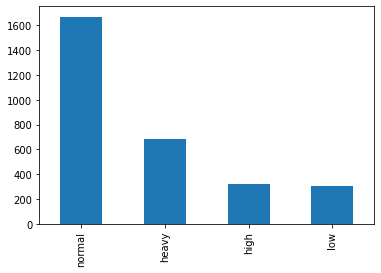

In [11]:
df['Traffic Situation'].value_counts().plot(kind='bar');

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2976 entries, 0 to 2975
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               2976 non-null   int64 
 1   Day of the week    2976 non-null   object
 2   CarCount           2976 non-null   int64 
 3   BikeCount          2976 non-null   int64 
 4   BusCount           2976 non-null   int64 
 5   TruckCount         2976 non-null   int64 
 6   Total              2976 non-null   int64 
 7   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(2)
memory usage: 209.2+ KB


In [13]:
# Data preprocessing
# Import label encoder 
from sklearn import preprocessing 

# label_encoder object knows 
# how to understand word labels. 
label_encoder = preprocessing.LabelEncoder() 

# Encode labels in column 'species'. 
df['Day of the week']= label_encoder.fit_transform(df['Day of the week'])
df['Traffic Situation']= label_encoder.fit_transform(df['Traffic Situation'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2976 entries, 0 to 2975
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Date               2976 non-null   int64
 1   Day of the week    2976 non-null   int32
 2   CarCount           2976 non-null   int64
 3   BikeCount          2976 non-null   int64
 4   BusCount           2976 non-null   int64
 5   TruckCount         2976 non-null   int64
 6   Total              2976 non-null   int64
 7   Traffic Situation  2976 non-null   int32
dtypes: int32(2), int64(6)
memory usage: 186.0 KB


In [15]:
df.columns

Index(['Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='object')

In [16]:
X = df[['Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total']]
y = df['Traffic Situation']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2380, 7), (2380,), (596, 7), (596,))

In [18]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# SVM

In [20]:
from sklearn.svm import SVC

clf = SVC(gamma='auto',probability=True)
# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

svm_acc = accuracy_score(y_pred, y_test)
svm_prec = precision_score(y_pred, y_test,average='weighted')
svm_rec = recall_score(y_pred, y_test,average='weighted')
svm_f1 = f1_score(y_pred, y_test,average='weighted')

In [21]:
storeResults('SVM',svm_acc,svm_prec,svm_rec,svm_f1)

# AdaBoost

In [22]:
from sklearn.ensemble import AdaBoostClassifier

clf = AdaBoostClassifier()
# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')

In [23]:
storeResults('AdaBoost',rf_acc,rf_prec,rf_rec,rf_f1)

# XGBoost

In [31]:
from xgboost import XGBClassifier

clf = XGBClassifier(n_estimators = 10, random_state=10)
# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

lr_acc = accuracy_score(y_pred, y_test)
lr_prec = precision_score(y_pred, y_test,average='weighted')
lr_rec = recall_score(y_pred, y_test,average='weighted')
lr_f1 = f1_score(y_pred, y_test,average='weighted')

In [25]:
storeResults('XGBoost',lr_acc,lr_prec,lr_rec,lr_f1)

# Voting Classifier

In [27]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

clf1 = BaggingClassifier(RandomForestClassifier(),n_estimators=10, random_state=0)
clf2 = DecisionTreeClassifier(random_state=10)

eclf1 = VotingClassifier(estimators=[('bagging', clf1), ('dt', clf2)], voting='soft')
eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

vot_acc = accuracy_score(y_pred, y_test)
vot_prec = precision_score(y_pred, y_test,average='weighted')
vot_rec = recall_score(y_pred, y_test,average='weighted')
vot_f1 = f1_score(y_pred, y_test,average='weighted')

In [28]:
storeResults('Voting Classifier',vot_acc,vot_prec,vot_rec,vot_f1)

# Comparison

In [29]:
#creating dataframe
import pandas as pd
import numpy as np
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'f1_score' : f1score,
                        'Recall'   : recall,
                        'Precision': precision,
                                                
                      })

In [30]:
result

,ML Model,Accuracy,f1_score,Recall,Precision
0,SVM,0.57,0.724,0.57,0.994
1,AdaBoost,0.57,0.726,0.57,1.000
2,XGBoost,1.00,1.000,1.00,1.000
3,Voting Classifier,1.00,1.000,1.00,1.000


# Modelling

In [33]:
import joblib
filename = 'model.sav'
joblib.dump(eclf1, filename)

['model.sav']

# Graph

In [34]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

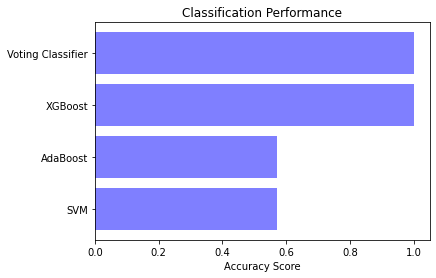

In [35]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

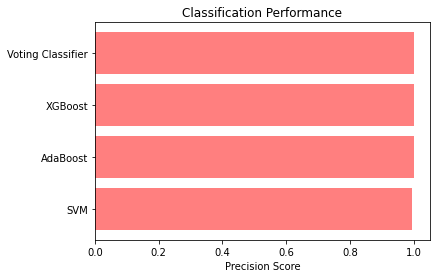

In [36]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

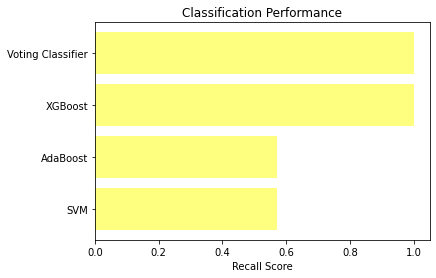

In [37]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

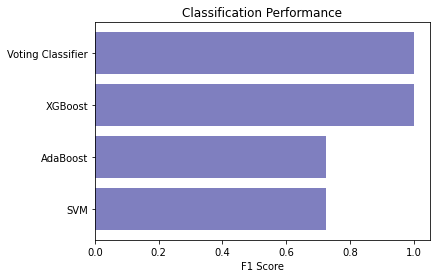

In [38]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()